In [2]:
import gymnasium as gym
import numpy as np
import math
import os
import configparser
from sb3_contrib.ppo_mask import MaskablePPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy
import matplotlib.pyplot as plt
from sb3_contrib.common.maskable.utils import get_action_masks



In [3]:
from src.hpc_env import HPCenv
from src.validation import Validation
from src.baseline import PercentileBaseline
from src.utils import mask_fn, get_config_as_dict
from src.carbon_intensity import CarbonIntensity

In [3]:

# Load config with explicit path and typed parsing
config = configparser.ConfigParser()
config_path = os.path.join(os.getcwd(), 'config_file', 'config.ini')
config.read(config_path)

['/Users/mikkeldahl/green-hpc-scheduler/config_file/config.ini']

## Model validation

In [4]:
val = Validation()
val.load_dir("results/train_and_eval/session_20251015-124011Z-ce2f2a/user_ci_disabled/eta_1/seed_1")
model = MaskablePPO.load("results/train_and_eval/session_20251015-124011Z-ce2f2a/user_ci_disabled/eta_1/seed_1/best_model.zip")
val.validate_model(n_eval_episodes=1,model=model,mode="test",)

Current secounds after start:  1894642
Current secounds after start:  3685662
Current secounds after start:  5872375
Current secounds after start:  8345900
Current secounds after start:  10650721
Current secounds after start:  12993316
Current secounds after start:  15236013
Current secounds after start:  17066124
Current secounds after start:  18763703


({'model': {'Validation Reward': -25195.190750000053,
   'val_objective': np.float64(0.2667207534534067),
   'Avg Wait': 23400.503782283693,
   'Max Wait': 3173619.0,
   'Avg Response': 27937.434000268564,
   'Avg Slowdown': 950.5469849856419,
   'Episode Duration': 19453132.0,
   'Carbon Emissions': 63645789.78450789,
   'Weighted Carbon Emissions': -63645789.78450789,
   'Reward Wait Component': -25195.190750000053,
   'Reward Carbon Component': 0.0,
   'Reward Total Component': -25195.190750000053,
   'System Utilization': 0.646351998340807,
   'Action Analysis': {'Total Actions': 93015,
    'Schedule Action Percentage': 24.018706660216093,
    'Fixed Delay Percentage': 57.81003064021932,
    'Wait Delay Percentage': 18.171262699564586,
    'Fixed Delays': {'600s': 11081,
     '300s': 42474,
     '7200s': 45,
     '1200s': 133,
     '3600s': 32,
     '14400s': 7},
    'Wait for Jobs': {'4 jobs': 14891, '3 jobs': 2011}}}},
 {'model': {'rewards': [-25195.190750000053],
   'job_schedul

In [4]:
val = Validation()
val.load_dir("results/CI_B8192_RC_LR-00001_ETA1.0_C-None_Lu__20251012-163316Z-d4e4b0")
processed_stats_baselines, raw_stats_baselines = val.run_baselines(n_eval_episodes=1, mode="validation")

Executing baseline:  FCFS Baseline
Episode  0
Executing baseline:  10-percentile Baseline
Episode  0
Executing baseline:  25-percentile Baseline
Episode  0
Executing baseline:  50-percentile Baseline
Episode  0


In [5]:
processed_stats_baselines

{'FCFS Baseline': {'Validation Reward': -2550.8613000000114,
  'Avg Wait': 6241.402740396379,
  'Max Wait': 533605.0,
  'Avg Response': 10793.021531685834,
  'Avg Slowdown': 177.4515107448421,
  'Episode Duration': 7837750.0,
  'Carbon Emissions': 28091754.682081796,
  'Weighted Carbon Emissions': -28091754.682081796,
  'System Utilization': 0.5823901774464929,
  'Action Analysis': {'Total Actions': 23851,
   'Schedule Action Percentage': 34.271099744245525,
   'Fixed Delay Percentage': 0.1383589786591757,
   'Wait Delay Percentage': 65.5905412770953,
   'Fixed Delays': {'300s': 33},
   'Wait for Jobs': {'1 jobs': 15644}}},
 '10-percentile Baseline': {'Validation Reward': -306707.1403999999,
  'Avg Wait': 8541616.890017128,
  'Max Wait': 25598582.0,
  'Avg Response': 8546168.508808417,
  'Avg Slowdown': 392264.1648802733,
  'Episode Duration': 33245897.0,
  'Carbon Emissions': 21023966.07749543,
  'Weighted Carbon Emissions': -21023966.07749543,
  'System Utilization': 0.13729900604821

In [6]:
val = Validation()
val.load_dir("results/CI_B8192_RC_LR-00001_ETA1.0_C-None_Lu__20251012-163316Z-d4e4b0")
processed_stats_baselines, raw_stats_baselines = val.run_baselines(n_eval_episodes=1, mode="test")

Executing baseline:  FCFS Baseline
Episode  0
Executing baseline:  10-percentile Baseline
Episode  0
Executing baseline:  25-percentile Baseline
Episode  0
Executing baseline:  50-percentile Baseline
Episode  0


In [7]:
processed_stats_baselines

{'FCFS Baseline': {'Validation Reward': -13835.874450000014,
  'Avg Wait': 12386.083389284275,
  'Max Wait': 736229.0,
  'Avg Response': 16923.013607269146,
  'Avg Slowdown': 482.3020010134192,
  'Episode Duration': 19461922.0,
  'Carbon Emissions': 64247149.32483153,
  'Weighted Carbon Emissions': -64247149.32483153,
  'System Utilization': 0.6460600726992689,
  'Action Analysis': {'Total Actions': 65472,
   'Schedule Action Percentage': 34.122983870967744,
   'Fixed Delay Percentage': 0.0855327468230694,
   'Wait Delay Percentage': 65.7914833822092,
   'Fixed Delays': {'300s': 56},
   'Wait for Jobs': {'1 jobs': 43075}}},
 '10-percentile Baseline': {'Validation Reward': -889696.7121,
  'Avg Wait': 29495674.07524283,
  'Max Wait': 65580089.0,
  'Avg Response': 29500211.005460814,
  'Avg Slowdown': 1394770.6007815606,
  'Episode Duration': 84902059.0,
  'Carbon Emissions': 46649788.17967203,
  'Weighted Carbon Emissions': -46649788.17967203,
  'System Utilization': 0.14809500370523995,

In [8]:
raw_stats_baselines

{'FCFS Baseline': {'rewards': [-13835.874450000014],
  'action_traces': [[{'step': 1,
     'action_index': 0,
     'action_type': 'schedule',
     'timestamp_before': 0,
     'timestamp_after': 0,
     'scheduled_job_id': 1,
     'scheduled_job_procs': 8,
     'scheduled_job_run_time': 68,
     'delay_kind': None,
     'delay_value': None,
     'events': {'arrivals': [], 'completions': []},
     'queue_len_before': 1,
     'running_len_before': 0,
     'queue_len_after': 0,
     'running_len_after': 1,
     'scheduled_job_submit_time': 0,
     'scheduled_job_wait_time': 0,
     'scheduled_job_nodes': 8},
    {'step': 2,
     'action_index': 264,
     'action_type': 'delay',
     'timestamp_before': 68,
     'timestamp_after': 328,
     'scheduled_job_id': None,
     'scheduled_job_procs': None,
     'scheduled_job_run_time': None,
     'delay_kind': 'wait',
     'delay_value': 1,
     'events': {'arrivals': [2], 'completions': []},
     'queue_len_before': 0,
     'running_len_before':

In [9]:
processed_stats_baselines

{'FCFS Baseline': {'Validation Reward': -13835.874450000014,
  'Avg Wait': 12386.083389284275,
  'Max Wait': 736229.0,
  'Avg Response': 16923.013607269146,
  'Avg Slowdown': 482.3020010134192,
  'Episode Duration': 19461922.0,
  'Carbon Emissions': 64247149.32483153,
  'Weighted Carbon Emissions': -64247149.32483153,
  'System Utilization': 0.6460600726992689,
  'Action Analysis': {'Total Actions': 65472,
   'Schedule Action Percentage': 34.122983870967744,
   'Fixed Delay Percentage': 0.0855327468230694,
   'Wait Delay Percentage': 65.7914833822092,
   'Fixed Delays': {'300s': 56},
   'Wait for Jobs': {'1 jobs': 43075}}},
 '10-percentile Baseline': {'Validation Reward': -889696.7121,
  'Avg Wait': 29495674.07524283,
  'Max Wait': 65580089.0,
  'Avg Response': 29500211.005460814,
  'Avg Slowdown': 1394770.6007815606,
  'Episode Duration': 84902059.0,
  'Carbon Emissions': 46649788.17967203,
  'Weighted Carbon Emissions': -46649788.17967203,
  'System Utilization': 0.14809500370523995,

In [10]:
processed_stats_baselines

{'FCFS Baseline': {'Validation Reward': -13835.874450000014,
  'Avg Wait': 12386.083389284275,
  'Max Wait': 736229.0,
  'Avg Response': 16923.013607269146,
  'Avg Slowdown': 482.3020010134192,
  'Episode Duration': 19461922.0,
  'Carbon Emissions': 64247149.32483153,
  'Weighted Carbon Emissions': -64247149.32483153,
  'System Utilization': 0.6460600726992689,
  'Action Analysis': {'Total Actions': 65472,
   'Schedule Action Percentage': 34.122983870967744,
   'Fixed Delay Percentage': 0.0855327468230694,
   'Wait Delay Percentage': 65.7914833822092,
   'Fixed Delays': {'300s': 56},
   'Wait for Jobs': {'1 jobs': 43075}}},
 '10-percentile Baseline': {'Validation Reward': -889696.7121,
  'Avg Wait': 29495674.07524283,
  'Max Wait': 65580089.0,
  'Avg Response': 29500211.005460814,
  'Avg Slowdown': 1394770.6007815606,
  'Episode Duration': 84902059.0,
  'Carbon Emissions': 46649788.17967203,
  'Weighted Carbon Emissions': -46649788.17967203,
  'System Utilization': 0.14809500370523995,

In [11]:
val.load_dir("results/lunar_george")
val.render_timeseries_plot(raw_stats['25-percentile Baseline']['action_traces'])

FileNotFoundError: Configuration file not found at '/Users/mikkeldahl/green-hpc-scheduler/results/lunar_george/config.json'. Please ensure it exists.

In [ ]:
val.load_dir("results/CI_B4096_RC_LR-00001_ETA0.0_C-None_Lu")
val.render_timeseries_plot(raw_stats['10-percentile Baseline']['action_traces'])

FileNotFoundError: Configuration file not found at '/Users/mikkeldahl/green-hpc-scheduler/results/CI_B4096_RC_LR-00001_ETA0.0_C-None_Lu/config.json'. Please ensure it exists.

In [ ]:
val.render_timeseries_plot(raw_stats['10-percentile Baseline']['action_traces'])

{'FCFS Baseline': {'Avg Wait': np.float64(4552.721755725191),
  'Max Wait': np.float64(4552.721755725191),
  'Avg Response': np.float64(8991.09351145038),
  'Avg Slowdown': np.float64(127.53263829568381),
  'Carbon Emissions': np.float64(9349788.624349324),
  'Weighted Carbon Emissions': np.float64(-9349788.624349324),
  'System Utilization': np.float64(0.45633334506960394),
  'Action Analysis': {'Total Actions': 10603,
   'Schedule Action Percentage': 24.70998773931906,
   'Fixed Delay Percentage': 24.38932377628973,
   'Wait Delay Percentage': 50.90068848439121,
   'Fixed Delays': {'300s': 2586},
   'Wait for Jobs': {'1 jobs': 5397}}},
 '10-percentile Baseline': {'Avg Wait': np.float64(6431648.060305344),
  'Max Wait': np.float64(6431648.060305344),
  'Avg Response': np.float64(6436086.432061069),
  'Avg Slowdown': np.float64(289532.42415359936),
  'Carbon Emissions': np.float64(6740089.32170967),
  'Weighted Carbon Emissions': np.float64(-6740089.32170967),
  'System Utilization': n

In [ ]:
val = Validation()
val.load_dir("results/lunar_george")
processed_stats_wait_min, raw_stats_wait_min  = val.validate_policy(n_eval_episodes=1, checkpoints=None, mode="validation")

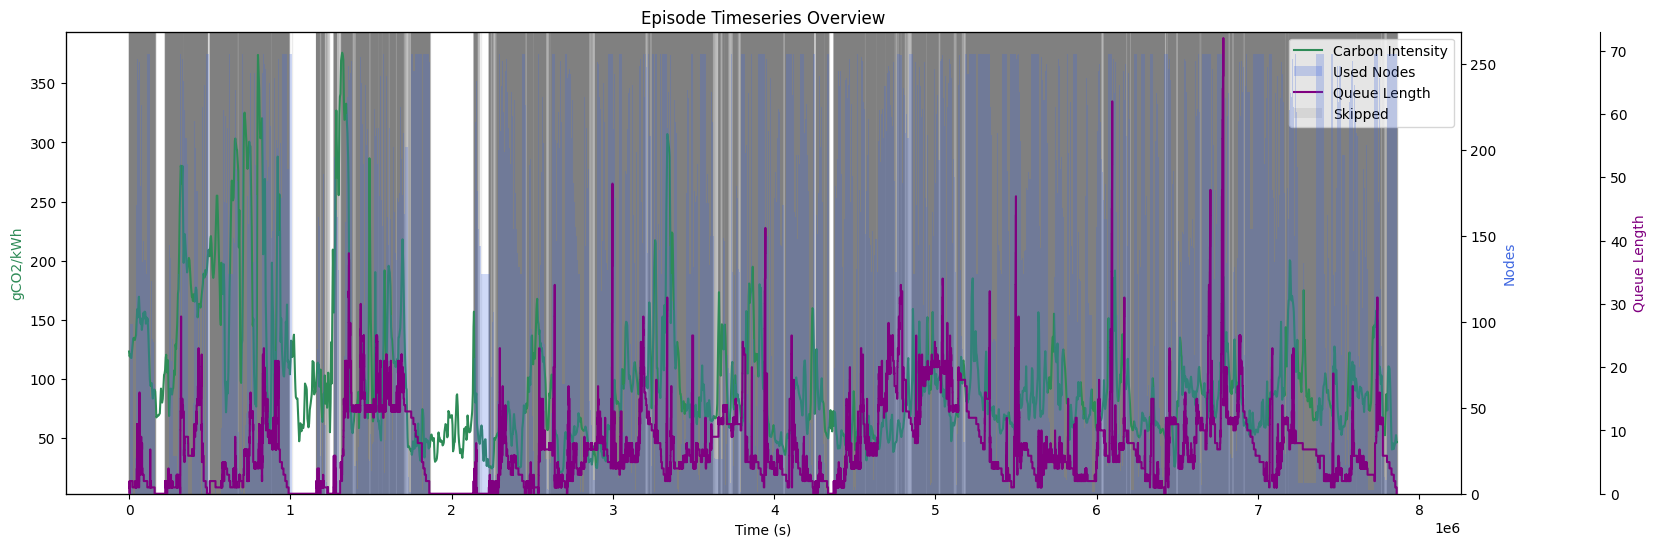

('renderings/timeseries.png', <Figure size 1800x600 with 3 Axes>)

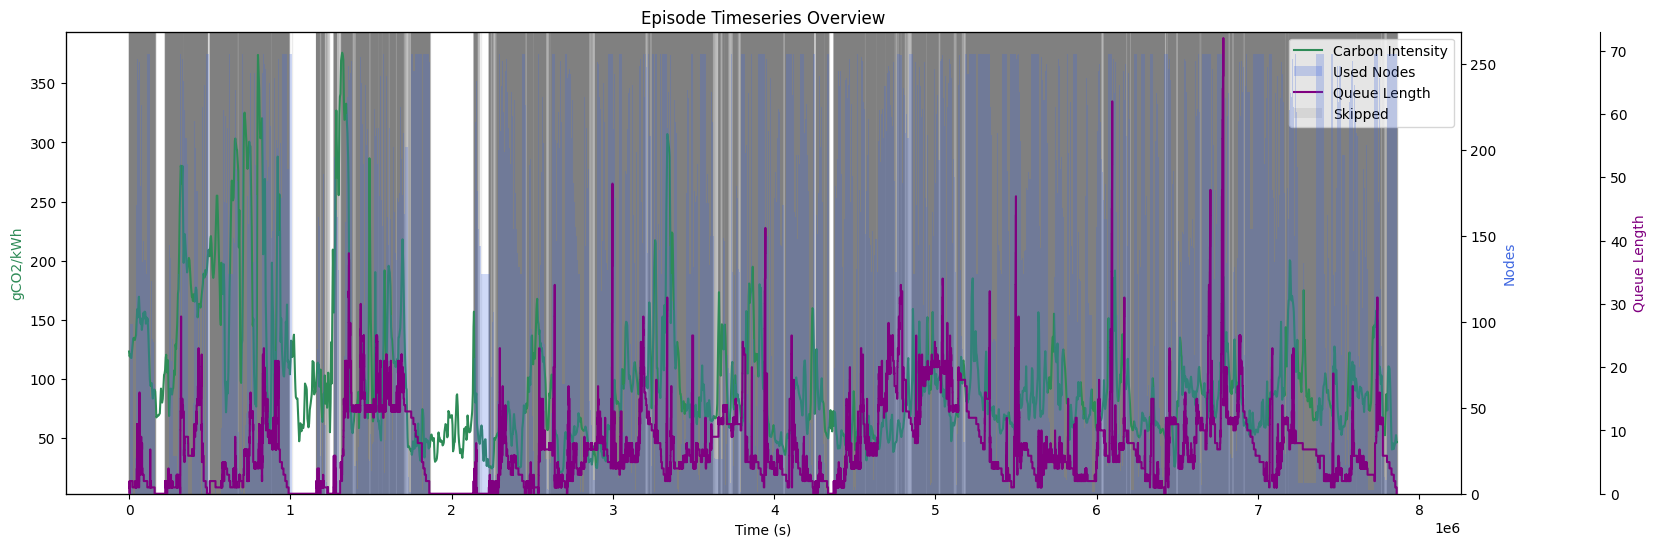

In [ ]:
val.render_timeseries_plot(raw_stats_wait_min['seed_7_393216_steps.zip']['action_traces'])

In [ ]:
processed_stats_wait_min

{'seed_7_1048576_steps.zip': {'Validation Reward': -1174392.488068277,
  'Avg Wait': 33136.508930756056,
  'Max Wait': 8059689.0,
  'Avg Response': 37688.12772204551,
  'Avg Slowdown': 716.6052572592106,
  'Episode Duration': 8117964.0,
  'Carbon Emissions': 27424970.563831527,
  'Weighted Carbon Emissions': -27424970.563831527,
  'System Utilization': 0.5622873682713116,
  'Action Analysis': {'Total Actions': 46338,
   'Schedule Action Percentage': 17.63994993310026,
   'Fixed Delay Percentage': 80.13725236307134,
   'Wait Delay Percentage': 2.2227977038283915,
   'Fixed Delays': {'300s': 37134},
   'Wait for Jobs': {'2 jobs': 707, '1 jobs': 323}}},
 'seed_7_1179648_steps.zip': {'Validation Reward': -1563615.574400918,
  'Avg Wait': 43077.719721066795,
  'Max Wait': 8232458.0,
  'Avg Response': 47629.338512356255,
  'Avg Slowdown': 1067.1575873683928,
  'Episode Duration': 8311015.0,
  'Carbon Emissions': 27602779.698500086,
  'Weighted Carbon Emissions': -27602779.698500086,
  'Syste

In [ ]:
val.render_timeseries_plot(raw_stats['seed_1_1500000_steps']['action_traces'])

KeyError: 'seed_1_1500000_steps'

### Best models in eta sweep

eta = 100,
seed_7_1310720_steps
eta = 50
seed_7_1802240_steps
eta = 200 
seed_7_655360_steps


In [ ]:
val = Validation()
val.load_dir("results/eta_sweep/CI_B8192_RC_LR-00000_ETA50.0_C-None_Lu")
results, raw_stats = val.validate_policy(n_eval_episodes=1, checkpoints=["seed_7_1802240_steps"], mode="test")

In [ ]:
results

{'seed_7_1802240_steps': {'Validation Reward': -1166340.358850961,
  'Avg Wait': 165239.27125016786,
  'Max Wait': 19967285.0,
  'Avg Response': 169776.20146815272,
  'Avg Slowdown': 5333.514747771977,
  'Episode Duration': 21032265.0,
  'Carbon Emissions': 61796374.36460751,
  'Weighted Carbon Emissions': -61796374.36460751,
  'System Utilization': 0.5978229516501194,
  'Action Analysis': {'Total Actions': 69759,
   'Schedule Action Percentage': 32.0259751429923,
   'Fixed Delay Percentage': 48.929887183015815,
   'Wait Delay Percentage': 19.044137673991887,
   'Fixed Delays': {'600s': 1085,
    '300s': 687,
    '7200s': 11,
    '14400s': 4644,
    '1800s': 304,
    '3600s': 24657,
    '43200s': 2745},
   'Wait for Jobs': {'2 jobs': 4901, '1 jobs': 8384}}}}

In [ ]:
val = Validation()
val.load_dir("results/eta_sweep/CI_B8192_RC_LR-00000_ETA50.0_C-None_Lu")
results, raw_stats = val.validate_policy(n_eval_episodes=1, checkpoints=["seed_7_1802240_steps"], mode="test")

FileNotFoundError: Configuration file not found at '/Users/mikkeldahl/green-hpc-scheduler/results/eta_sweep/CI_B8192_RC_LR-00000_ETA200.0_C-None_Lu/seed_7_1310720_steps/config.json'. Please ensure it exists.

In [ ]:
results

{'seed_7_1802240_steps': {'Validation Reward': -1371988.8360002819,
  'Avg Wait': 101121.37415514077,
  'Max Wait': 19334874.0,
  'Avg Response': 105658.30437312565,
  'Avg Slowdown': 2503.470562594468,
  'Episode Duration': 20570115.0,
  'Carbon Emissions': 62195518.014480196,
  'Weighted Carbon Emissions': -62195518.014480196,
  'System Utilization': 0.6112542755442787,
  'Action Analysis': {'Total Actions': 70329,
   'Schedule Action Percentage': 31.766412148615792,
   'Fixed Delay Percentage': 47.79678368809453,
   'Wait Delay Percentage': 20.436804163289683,
   'Fixed Delays': {'600s': 539,
    '300s': 2195,
    '7200s': 13,
    '14400s': 3914,
    '1800s': 852,
    '3600s': 25772,
    '43200s': 330},
   'Wait for Jobs': {'2 jobs': 1169, '1 jobs': 13204}}}}

In [ ]:
val = Validation()
val.load_dir("results/eta_sweep/CI_B8192_RC_LR-00000_ETA200.0_C-None_Lu")
results, raw_stats = val.validate_policy(n_eval_episodes=1, checkpoints=["seed_7_655360_steps"], mode="test")

In [ ]:
results

{'seed_7_655360_steps': {'Validation Reward': -2029468.3635949432,
  'Avg Wait': 80331.43149366636,
  'Max Wait': 19357916.0,
  'Avg Response': 84868.36171165122,
  'Avg Slowdown': 1941.0599911336137,
  'Episode Duration': 20119259.0,
  'Carbon Emissions': 61960902.54161472,
  'Weighted Carbon Emissions': -61960902.54161472,
  'System Utilization': 0.6249519797020109,
  'Action Analysis': {'Total Actions': 69927,
   'Schedule Action Percentage': 31.949032562529496,
   'Fixed Delay Percentage': 49.9578131479972,
   'Wait Delay Percentage': 18.093154289473308,
   'Fixed Delays': {'600s': 791,
    '300s': 2149,
    '7200s': 13,
    '14400s': 11219,
    '1800s': 260,
    '43200s': 987,
    '3600s': 19515},
   'Wait for Jobs': {'2 jobs': 1546, '1 jobs': 11106}}}}